In [3]:
#1 Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, roc_curve,
                              confusion_matrix, classification_report)
sns.set_style("whitegrid")
pd.set_option("display.max_columns", None)                             

In [4]:
#2 Load and Parse the Raw Dataset
raw = pd.read_excel("bankruptcy-prevention (1).xlsx", header=None)

header_row = raw.iloc[0, 0]
data_rows = raw.iloc[1:, 0]

column_names = [
    "industrial_risk", "management_risk", "financial_flexibility",
    "credibility", "competitiveness", "operating_risk", "class",
]

split_rows = data_rows.str.split(";")
df = pd.DataFrame(split_rows.tolist(), columns=column_names)

feature_cols = column_names[:-1]
df[feature_cols] = df[feature_cols].astype(float)
df["class"] = df["class"].str.strip()
df = df.reset_index(drop=True)

df.head()

,industrial_risk,management_risk,financial_flexibility,credibility,competitiveness,operating_risk,class
0,0.5,1.0,0.0,0.0,0.0,0.5,bankruptcy
1,0.0,1.0,0.0,0.0,0.0,1.0,bankruptcy
2,1.0,0.0,0.0,0.0,0.0,1.0,bankruptcy
3,0.5,0.0,0.0,0.5,0.0,1.0,bankruptcy
4,1.0,1.0,0.0,0.0,0.0,1.0,bankruptcy


In [5]:
#3 Encode Target Variable
le= LabelEncoder()
df["class_encoded"]= le.fit_transform(df["class"])
print("Label mapping:", dict(zip(le.classes_, le.transform(le.classes_))))

Label mapping: {'bankruptcy': 0, 'non-bankruptcy': 1}


In [6]:
#4 Define Features(X) and Target(y)
feature_cols=["industrial_risk", "management_risk", "financial_flexibility",
                 "credibility", "competitiveness", "operating_risk"]
X=df[feature_cols]
y=df["class_encoded"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (250, 6)
y shape: (250,)


In [7]:
#5 Train/Test split
X_train, X_test, y_train, y_test= train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print("Training set size:", X_train.shape[0])
print("Testing set size:", X_test.shape[0])
print("\nTrain class balance:\n", y_train.value_counts(normalize=True))
print("\nTest class balance:\n", y_test.value_counts(normalize=True))

Training set size: 200
Testing set size: 50

Train class balance:
 class_encoded
1    0.57
0    0.43
Name: proportion, dtype: float64

Test class balance:
 class_encoded
1    0.58
0    0.42
Name: proportion, dtype: float64


In [8]:
#MODEL 1- Logistic Regression
#6 Train Logistic Regression
log_reg= LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train, y_train)

y_pred_lr= log_reg.predict(X_test)
y_proba_lr= log_reg.predict_proba(X_test)[:, 1]

print("Logistic Regression trained successfully")

Logistic Regression trained successfully


In [9]:
all_results = []   # every model's metrics will get appended here

In [10]:
#7 Logistic regression: Metrics
acc_lr = accuracy_score(y_test, y_pred_lr)
prec_lr = precision_score(y_test, y_pred_lr)
rec_lr = recall_score(y_test, y_pred_lr)
f1_lr = f1_score(y_test, y_pred_lr)
auc_lr = roc_auc_score(y_test, y_proba_lr)

print("=== Logistic Regression ===")
print(f"Accuracy : {acc_lr:.4f}")
print(f"Precision: {prec_lr:.4f}")
print(f"Recall   : {rec_lr:.4f}")
print(f"F1 Score : {f1_lr:.4f}")
print(f"ROC-AUC  : {auc_lr:.4f}")

all_results.append({"Model": "Logistic Regression", "Accuracy": acc_lr,
                     "Precision": prec_lr, "Recall": rec_lr, "F1 Score": f1_lr, "ROC-AUC": auc_lr})

=== Logistic Regression ===
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000
ROC-AUC  : 1.0000


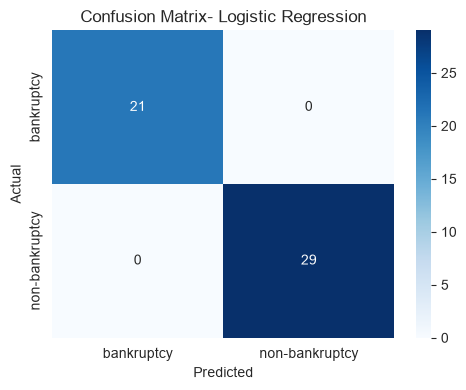

                precision    recall  f1-score   support

    bankruptcy       1.00      1.00      1.00        21
non-bankruptcy       1.00      1.00      1.00        29

      accuracy                           1.00        50
     macro avg       1.00      1.00      1.00        50
  weighted avg       1.00      1.00      1.00        50



In [11]:
#8 Logistic Regression: Confusion Matrix
cm_lr= confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(5,4))
sns.heatmap(cm_lr, annot=True, fmt="d", cmap="Blues",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix- Logistic Regression")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_lr, target_names=le.classes_))

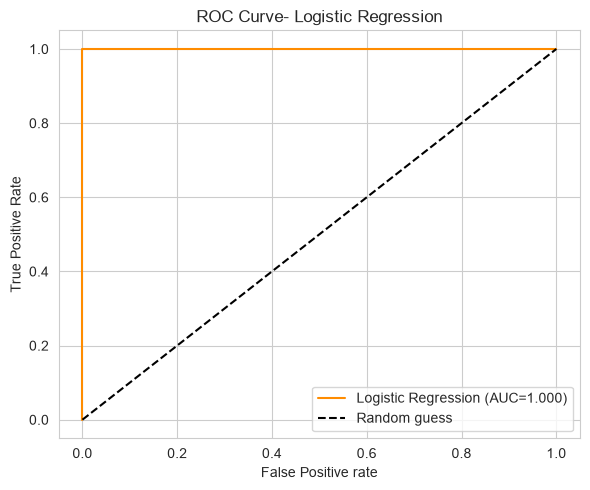

In [12]:
#9 Logistic Regression: ROC Curve
fpr_lr, tpr_lr, _=roc_curve(y_test, y_proba_lr)

plt.figure(figsize=(6,5))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC={auc_lr:.3f})", color="darkorange")
plt.plot([0,1], [0,1], "k--", label="Random guess")
plt.xlabel("False Positive rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve- Logistic Regression")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [13]:
#MODEL 2 DECISION TREE
#10 train DEcision Tree
dtree= DecisionTreeClassifier(random_state=42)
dtree.fit(X_train, y_train)
y_pred_dt=dtree.predict(X_test)
yProba_dt= dtree.predict_proba(X_test)[:,1]
print("Decision tree trained Successfully")

Decision tree trained Successfully


In [14]:
#11 Decision Tree Metrics
acc_dt= accuracy_score(y_test, y_pred_dt)
prec_dt=precision_score(y_test, y_pred_dt)
rec_dt=recall_score(y_test, y_pred_dt)
f1_dt=f1_score(y_test, y_pred_dt)
auc_dt=roc_auc_score(y_test, yProba_dt)

print("=== Decision Tree ===")
print(f"Accuracy : {acc_dt:.4f}")
print(f"Precision : {prec_dt:.4f}")
print(f"Recall : {rec_dt:.4f}")
print(f"F1-Score : {f1_dt:.4f}")
print(f"AUC-ROC : {auc_dt:.4f}")

all_results.append({"model": "Decision Tree", "Accuracy": acc_dt, "Precision": prec_dt,
                    "Recall": rec_dt, "F1-Score": f1_dt, "AUC-ROC": auc_dt })

=== Decision Tree ===
Accuracy : 1.0000
Precision : 1.0000
Recall : 1.0000
F1-Score : 1.0000
AUC-ROC : 1.0000


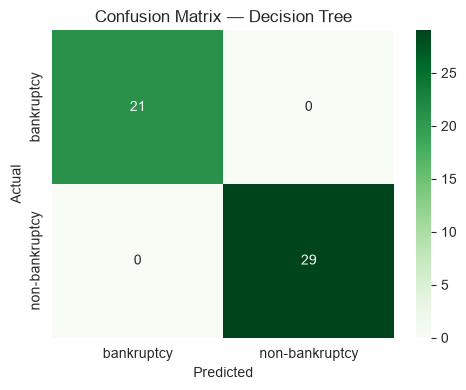

                precision    recall  f1-score   support

    bankruptcy       1.00      1.00      1.00        21
non-bankruptcy       1.00      1.00      1.00        29

      accuracy                           1.00        50
     macro avg       1.00      1.00      1.00        50
  weighted avg       1.00      1.00      1.00        50



In [15]:
#12 Decision Tree: Confusion Matrix
cm_dt = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_dt, annot=True, fmt="d", cmap="Greens",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Decision Tree")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_dt, target_names=le.classes_))

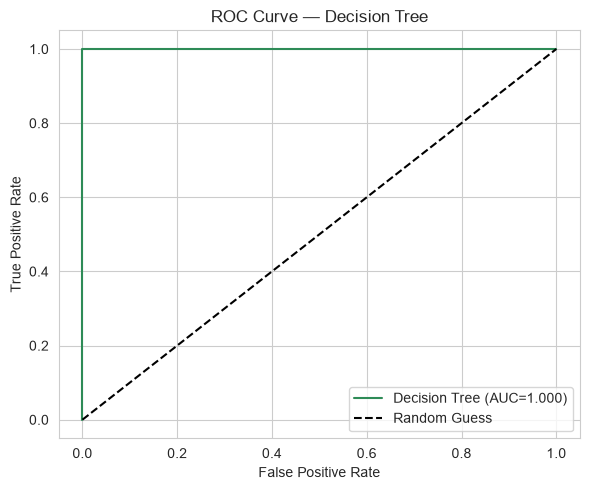

In [16]:
#13 Decision Tree: ROC Curve
fpr_dt, tpr_dt, _= roc_curve(y_test, y_pred_dt)
plt.figure(figsize=(6, 5))
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC={auc_dt:.3f})", color="seagreen")
plt.plot([0,1], [0,1], "k--", label="Random Guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Decision Tree")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

C:\Users\sanum\AppData\Local\Temp\ipykernel_31440\2954376411.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_dt, x="Importance", y="Feature", palette="Greens_r")


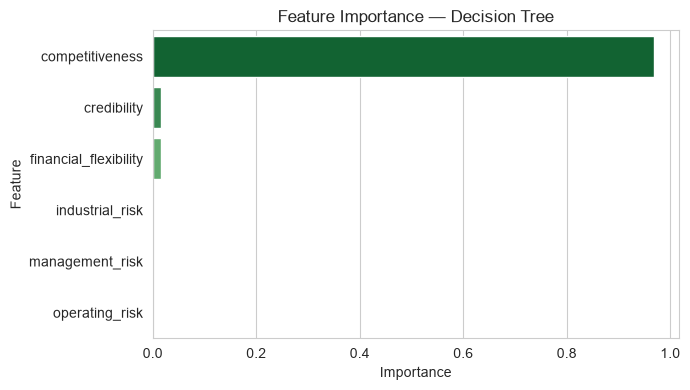

,Feature,Importance
4,competitiveness,0.967909
3,credibility,0.016791
2,financial_flexibility,0.015300
0,industrial_risk,0.000000
1,management_risk,0.000000
5,operating_risk,0.000000


In [17]:
#14 Decision tree: Feature Importance
importance_dt = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": dtree.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(7, 4))
sns.barplot(data=importance_dt, x="Importance", y="Feature", palette="Greens_r")
plt.title("Feature Importance — Decision Tree")
plt.tight_layout()
plt.show()

importance_dt

In [18]:
#MODEL 3 - RANDOM FOREST
#15 Train Random Forest model
rf= RandomForestClassifier(n_estimators=200, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf= rf.predict(X_test)
y_proba_rf= rf.predict_proba(X_test)[:, 1]
print("Random Forest trained successfully")

Random Forest trained successfully


In [19]:
#16 Random Forest: Metrics
acc_rf=accuracy_score(y_test, y_pred_rf)
prec_rf=precision_score(y_test, y_pred_rf)
rec_rf=recall_score(y_test, y_pred_rf)
f1_rf=f1_score(y_test, y_pred_rf)
auc_rf=roc_auc_score(y_test, y_proba_rf)

print("=== Random Forest ===")
print(f"Accuracy : {acc_rf:.4f}")
print(f"Precision : {prec_rf:.4f}") 
print(f"Recall : {rec_rf:.4f}")
print(f"F1-Score : {f1_rf:.4f}")
print(f"AUC-ROC : {auc_rf:.4f}")

all_results.append({"model": "Random Forest", "Accuracy": acc_rf, "Precision": prec_rf,
                    "Recall": rec_rf, "F1-Score": f1_rf, "AUC-ROC": auc_rf })

=== Random Forest ===
Accuracy : 1.0000
Precision : 1.0000
Recall : 1.0000
F1-Score : 1.0000
AUC-ROC : 1.0000


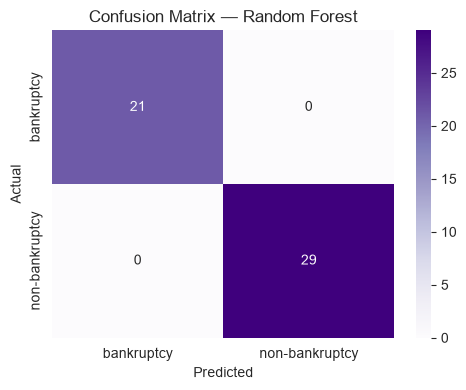

                precision    recall  f1-score   support

    bankruptcy       1.00      1.00      1.00        21
non-bankruptcy       1.00      1.00      1.00        29

      accuracy                           1.00        50
     macro avg       1.00      1.00      1.00        50
  weighted avg       1.00      1.00      1.00        50



In [20]:
#17 Random Forest: Confusion Matrix
cm_rf = confusion_matrix(y_test, y_pred_rf)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_rf, annot=True, fmt="d", cmap="Purples",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Random Forest")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_rf, target_names=le.classes_))

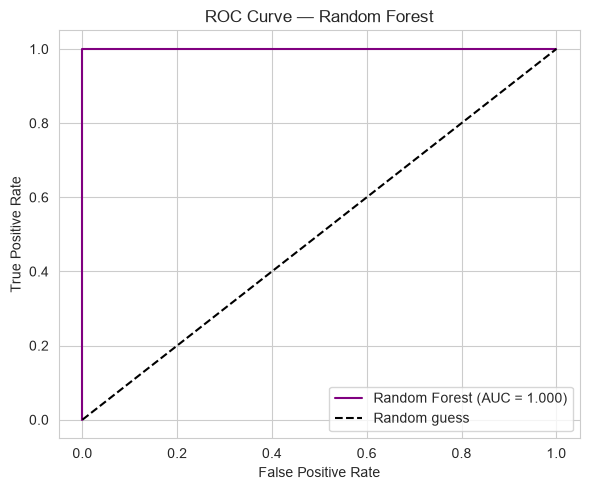

In [21]:
#18 Random Forest: ROC Curve
fpr_rf, tpr_rf, _ = roc_curve(y_test, y_proba_rf)

plt.figure(figsize=(6, 5))
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC = {auc_rf:.3f})", color="purple")
plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Random Forest")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

C:\Users\sanum\AppData\Local\Temp\ipykernel_31440\2907576586.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_rf, x="Importance", y="Feature", palette="Purples_r")


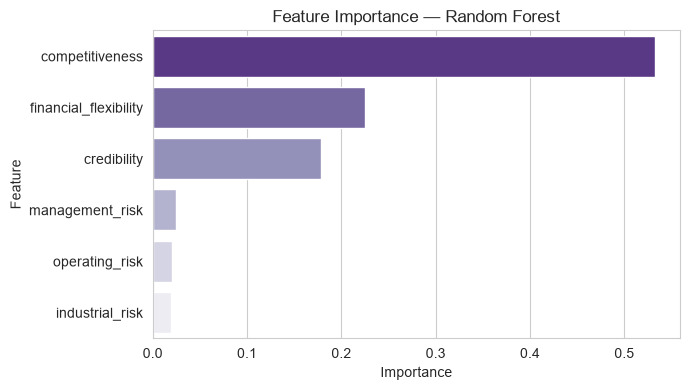

,Feature,Importance
4,competitiveness,0.532387
2,financial_flexibility,0.224590
3,credibility,0.178606
1,management_risk,0.024827
5,operating_risk,0.019906
0,industrial_risk,0.019684


In [22]:
#19 Random Forest: Feature Importance
importance_rf = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": rf.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(7, 4))
sns.barplot(data=importance_rf, x="Importance", y="Feature", palette="Purples_r")
plt.title("Feature Importance — Random Forest")
plt.tight_layout()
plt.show()

importance_rf

In [23]:
#MODEL 4 - GRADIENT BOOSTING
#20 Train Gradient Boosting MOdel
gb = GradientBoostingClassifier(random_state=42)
gb.fit(X_train, y_train)

y_pred_gb = gb.predict(X_test)
y_proba_gb = gb.predict_proba(X_test)[:, 1]

print("Gradient Boosting trained successfully.")

Gradient Boosting trained successfully.


In [24]:
#21 Gradient Boosting: Metrics
acc_gb = accuracy_score(y_test, y_pred_gb)
prec_gb = precision_score(y_test, y_pred_gb)
rec_gb = recall_score(y_test, y_pred_gb)
f1_gb = f1_score(y_test, y_pred_gb)
auc_gb = roc_auc_score(y_test, y_proba_gb)

print("=== Gradient Boosting ===")
print(f"Accuracy : {acc_gb:.4f}")
print(f"Precision: {prec_gb:.4f}")
print(f"Recall   : {rec_gb:.4f}")
print(f"F1 Score : {f1_gb:.4f}")
print(f"ROC-AUC  : {auc_gb:.4f}")

all_results.append({"Model": "Gradient Boosting", "Accuracy": acc_gb,
                     "Precision": prec_gb, "Recall": rec_gb, "F1 Score": f1_gb, "ROC-AUC": auc_gb})

=== Gradient Boosting ===
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000
ROC-AUC  : 1.0000


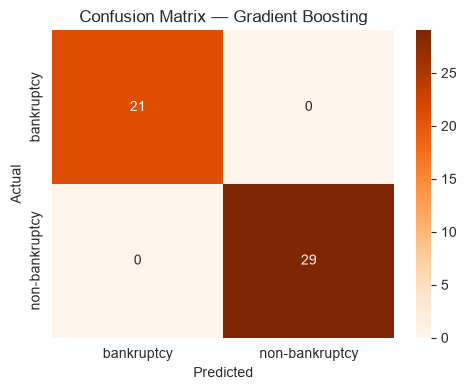

                precision    recall  f1-score   support

    bankruptcy       1.00      1.00      1.00        21
non-bankruptcy       1.00      1.00      1.00        29

      accuracy                           1.00        50
     macro avg       1.00      1.00      1.00        50
  weighted avg       1.00      1.00      1.00        50



In [25]:
#22 Gradient Boosting: Confusion Matrix
cm_gb = confusion_matrix(y_test, y_pred_gb)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_gb, annot=True, fmt="d", cmap="Oranges",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Gradient Boosting")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_gb, target_names=le.classes_))

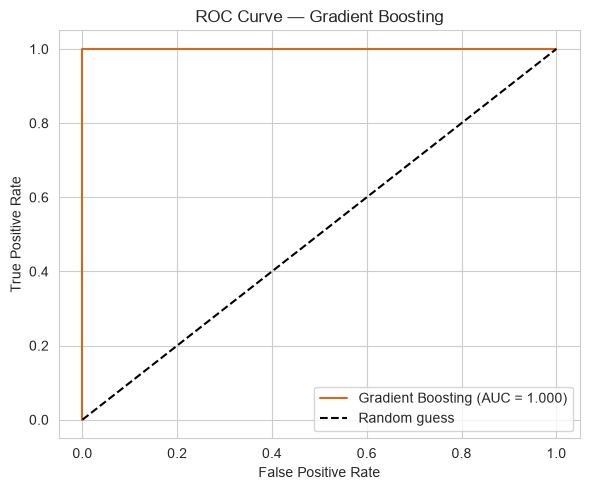

In [26]:
#23 Gradient Boosting: ROC Curve
fpr_gb, tpr_gb, _ = roc_curve(y_test, y_proba_gb)

plt.figure(figsize=(6, 5))
plt.plot(fpr_gb, tpr_gb, label=f"Gradient Boosting (AUC = {auc_gb:.3f})", color="chocolate")
plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Gradient Boosting")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()


C:\Users\sanum\AppData\Local\Temp\ipykernel_31440\3926980515.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importance_gb, x="Importance", y="Feature", palette="Oranges_r")


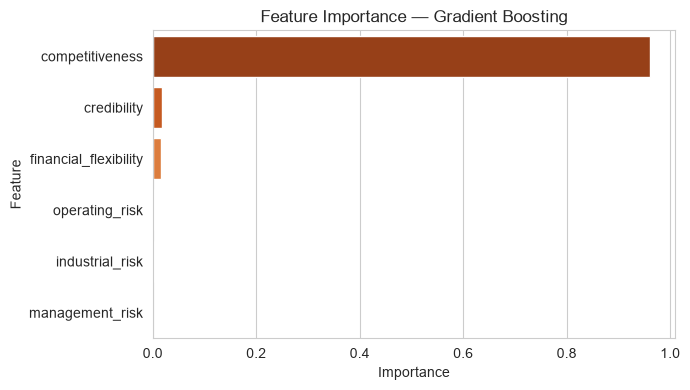

,Feature,Importance
4,competitiveness,9.616398e-01
3,credibility,1.699713e-02
2,financial_flexibility,1.680147e-02
5,operating_risk,2.282360e-03
0,industrial_risk,2.278984e-03
1,management_risk,2.449716e-07


In [27]:
#24 Gradient Boosting: Feature Importance
importance_gb = pd.DataFrame({
    "Feature": feature_cols,
    "Importance": gb.feature_importances_
}).sort_values("Importance", ascending=False)

plt.figure(figsize=(7, 4))
sns.barplot(data=importance_gb, x="Importance", y="Feature", palette="Oranges_r")
plt.title("Feature Importance — Gradient Boosting")
plt.tight_layout()
plt.show()

importance_gb

In [28]:
#MODEL 5 - Support Vector Machine (SVM)
#25 Train SVM
svm = SVC(probability=True, random_state=42)
svm.fit(X_train, y_train)

y_pred_svm = svm.predict(X_test)
y_proba_svm = svm.predict_proba(X_test)[:, 1]

print("SVM trained successfully.")

SVM trained successfully.


In [29]:
#26 SVM: Metrics
acc_svm = accuracy_score(y_test, y_pred_svm)
prec_svm = precision_score(y_test, y_pred_svm)
rec_svm = recall_score(y_test, y_pred_svm)
f1_svm = f1_score(y_test, y_pred_svm)
auc_svm = roc_auc_score(y_test, y_proba_svm)

print("=== SVM (RBF Kernel) ===")
print(f"Accuracy : {acc_svm:.4f}")
print(f"Precision: {prec_svm:.4f}")
print(f"Recall   : {rec_svm:.4f}")
print(f"F1 Score : {f1_svm:.4f}")
print(f"ROC-AUC  : {auc_svm:.4f}")

all_results.append({"Model": "SVM (RBF)", "Accuracy": acc_svm,
                     "Precision": prec_svm, "Recall": rec_svm, "F1 Score": f1_svm, "ROC-AUC": auc_svm})

=== SVM (RBF Kernel) ===
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000
ROC-AUC  : 1.0000


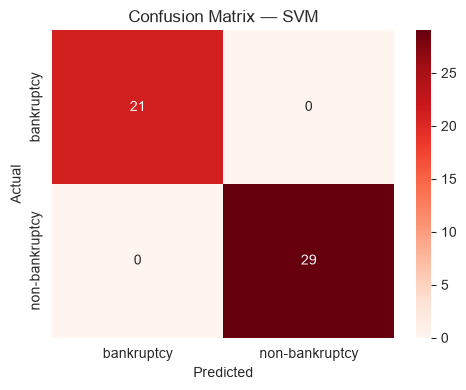

                precision    recall  f1-score   support

    bankruptcy       1.00      1.00      1.00        21
non-bankruptcy       1.00      1.00      1.00        29

      accuracy                           1.00        50
     macro avg       1.00      1.00      1.00        50
  weighted avg       1.00      1.00      1.00        50



In [30]:
#27 SVM: Confusion Matrix
cm_svm = confusion_matrix(y_test, y_pred_svm)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_svm, annot=True, fmt="d", cmap="Reds",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — SVM")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_svm, target_names=le.classes_))

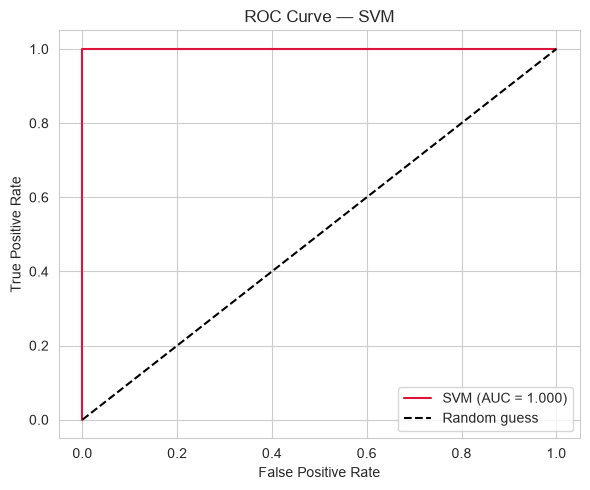

In [31]:
#28 SVM: ROC Curve
fpr_svm, tpr_svm, _ = roc_curve(y_test, y_proba_svm)

plt.figure(figsize=(6, 5))
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC = {auc_svm:.3f})", color="crimson")
plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — SVM")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [32]:
#MODEL 6 K- Nearest NEighbors (KNN)
#29 Train KNN
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)

y_pred_knn = knn.predict(X_test)
y_proba_knn = knn.predict_proba(X_test)[:, 1]

print("KNN trained successfully.")

KNN trained successfully.


In [33]:
#30 KNN: Metrics
acc_knn = accuracy_score(y_test, y_pred_knn)
prec_knn = precision_score(y_test, y_pred_knn)
rec_knn = recall_score(y_test, y_pred_knn)
f1_knn = f1_score(y_test, y_pred_knn)
auc_knn = roc_auc_score(y_test, y_proba_knn)

print("=== K-Nearest Neighbors (k=5) ===")
print(f"Accuracy : {acc_knn:.4f}")
print(f"Precision: {prec_knn:.4f}")
print(f"Recall   : {rec_knn:.4f}")
print(f"F1 Score : {f1_knn:.4f}")
print(f"ROC-AUC  : {auc_knn:.4f}")

all_results.append({"Model": "K-Nearest Neighbors", "Accuracy": acc_knn,
                     "Precision": prec_knn, "Recall": rec_knn, "F1 Score": f1_knn, "ROC-AUC": auc_knn})

=== K-Nearest Neighbors (k=5) ===
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000
ROC-AUC  : 1.0000


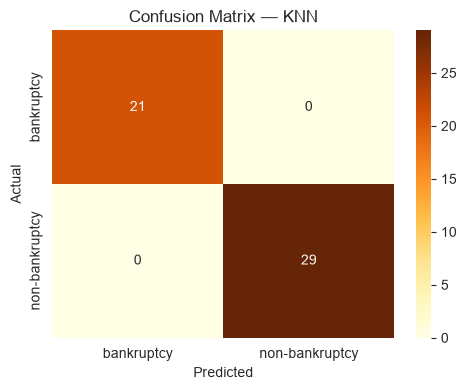

                precision    recall  f1-score   support

    bankruptcy       1.00      1.00      1.00        21
non-bankruptcy       1.00      1.00      1.00        29

      accuracy                           1.00        50
     macro avg       1.00      1.00      1.00        50
  weighted avg       1.00      1.00      1.00        50



In [34]:
#31 KNN: Confusion Matrix
cm_knn = confusion_matrix(y_test, y_pred_knn)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_knn, annot=True, fmt="d", cmap="YlOrBr",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — KNN")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_knn, target_names=le.classes_))

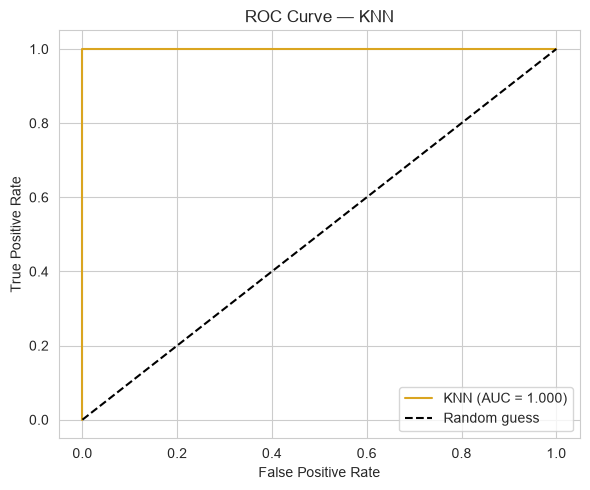

In [35]:
#32 KNN: ROC Curve
fpr_knn, tpr_knn, _ = roc_curve(y_test, y_proba_knn)

plt.figure(figsize=(6, 5))
plt.plot(fpr_knn, tpr_knn, label=f"KNN (AUC = {auc_knn:.3f})", color="goldenrod")
plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — KNN")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [36]:
#MODEL- 7 Naive Bayes
#33 Train Naive Bayes
nb = GaussianNB()
nb.fit(X_train, y_train)

y_pred_nb = nb.predict(X_test)
y_proba_nb = nb.predict_proba(X_test)[:, 1]

print("Naive Bayes trained successfully.")

Naive Bayes trained successfully.


In [37]:
#34 Naive Bayes: Metrics
acc_nb = accuracy_score(y_test, y_pred_nb)
prec_nb = precision_score(y_test, y_pred_nb)
rec_nb = recall_score(y_test, y_pred_nb)
f1_nb = f1_score(y_test, y_pred_nb)
auc_nb = roc_auc_score(y_test, y_proba_nb)

print("=== Naive Bayes ===")
print(f"Accuracy : {acc_nb:.4f}")
print(f"Precision: {prec_nb:.4f}")
print(f"Recall   : {rec_nb:.4f}")
print(f"F1 Score : {f1_nb:.4f}")
print(f"ROC-AUC  : {auc_nb:.4f}")

all_results.append({"Model": "Naive Bayes", "Accuracy": acc_nb,
                     "Precision": prec_nb, "Recall": rec_nb, "F1 Score": f1_nb, "ROC-AUC": auc_nb})

=== Naive Bayes ===
Accuracy : 0.9800
Precision: 0.9667
Recall   : 1.0000
F1 Score : 0.9831
ROC-AUC  : 1.0000


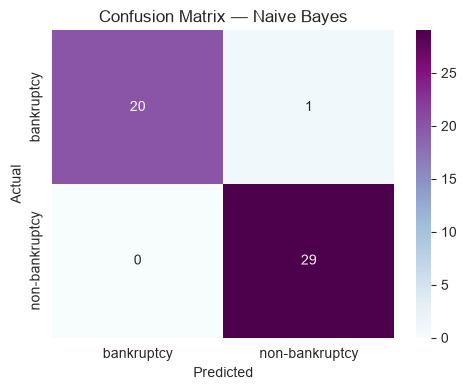

                precision    recall  f1-score   support

    bankruptcy       1.00      0.95      0.98        21
non-bankruptcy       0.97      1.00      0.98        29

      accuracy                           0.98        50
     macro avg       0.98      0.98      0.98        50
  weighted avg       0.98      0.98      0.98        50



In [38]:
#35 — Naive Bayes: Confusion Matrix
cm_nb = confusion_matrix(y_test, y_pred_nb)

plt.figure(figsize=(5, 4))
sns.heatmap(cm_nb, annot=True, fmt="d", cmap="BuPu",
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix — Naive Bayes")
plt.tight_layout()
plt.show()

print(classification_report(y_test, y_pred_nb, target_names=le.classes_))

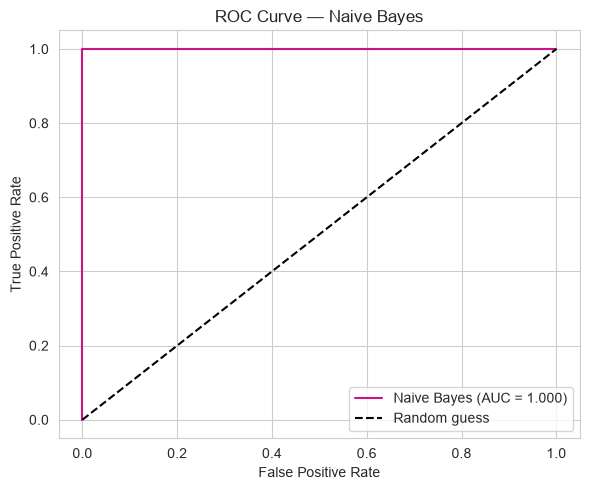

In [39]:
#36 — Naive Bayes: ROC Curve
fpr_nb, tpr_nb, _ = roc_curve(y_test, y_proba_nb)

plt.figure(figsize=(6, 5))
plt.plot(fpr_nb, tpr_nb, label=f"Naive Bayes (AUC = {auc_nb:.3f})", color="mediumvioletred")
plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve — Naive Bayes")
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

In [40]:
all_results = []

all_results.append({"Model": "Logistic Regression", "Accuracy": acc_lr, "Precision": prec_lr, "Recall": rec_lr, "F1 Score": f1_lr, "ROC-AUC": auc_lr})
all_results.append({"Model": "Decision Tree", "Accuracy": acc_dt, "Precision": prec_dt, "Recall": rec_dt, "F1 Score": f1_dt, "ROC-AUC": auc_dt})
all_results.append({"Model": "Random Forest", "Accuracy": acc_rf, "Precision": prec_rf, "Recall": rec_rf, "F1 Score": f1_rf, "ROC-AUC": auc_rf})
all_results.append({"Model": "Gradient Boosting", "Accuracy": acc_gb, "Precision": prec_gb, "Recall": rec_gb, "F1 Score": f1_gb, "ROC-AUC": auc_gb})
all_results.append({"Model": "SVM (RBF)", "Accuracy": acc_svm, "Precision": prec_svm, "Recall": rec_svm, "F1 Score": f1_svm, "ROC-AUC": auc_svm})
all_results.append({"Model": "K-Nearest Neighbors", "Accuracy": acc_knn, "Precision": prec_knn, "Recall": rec_knn, "F1 Score": f1_knn, "ROC-AUC": auc_knn})
all_results.append({"Model": "Naive Bayes", "Accuracy": acc_nb, "Precision": prec_nb, "Recall": rec_nb, "F1 Score": f1_nb, "ROC-AUC": auc_nb})

print(f"Total models collected: {len(all_results)}")

Total models collected: 7


#FINAL COMPARISON

In [41]:
#37 — Combined Results Table
results_df = pd.DataFrame(all_results).sort_values("Accuracy", ascending=False).reset_index(drop=True)
results_df

,Model,Accuracy,Precision,Recall,F1 Score,ROC-AUC
0,Logistic Regression,1.00,1.000000,1.0,1.000000,1.0
1,Decision Tree,1.00,1.000000,1.0,1.000000,1.0
2,Random Forest,1.00,1.000000,1.0,1.000000,1.0
3,Gradient Boosting,1.00,1.000000,1.0,1.000000,1.0
4,SVM (RBF),1.00,1.000000,1.0,1.000000,1.0
5,K-Nearest Neighbors,1.00,1.000000,1.0,1.000000,1.0
6,Naive Bayes,0.98,0.966667,1.0,0.983051,1.0


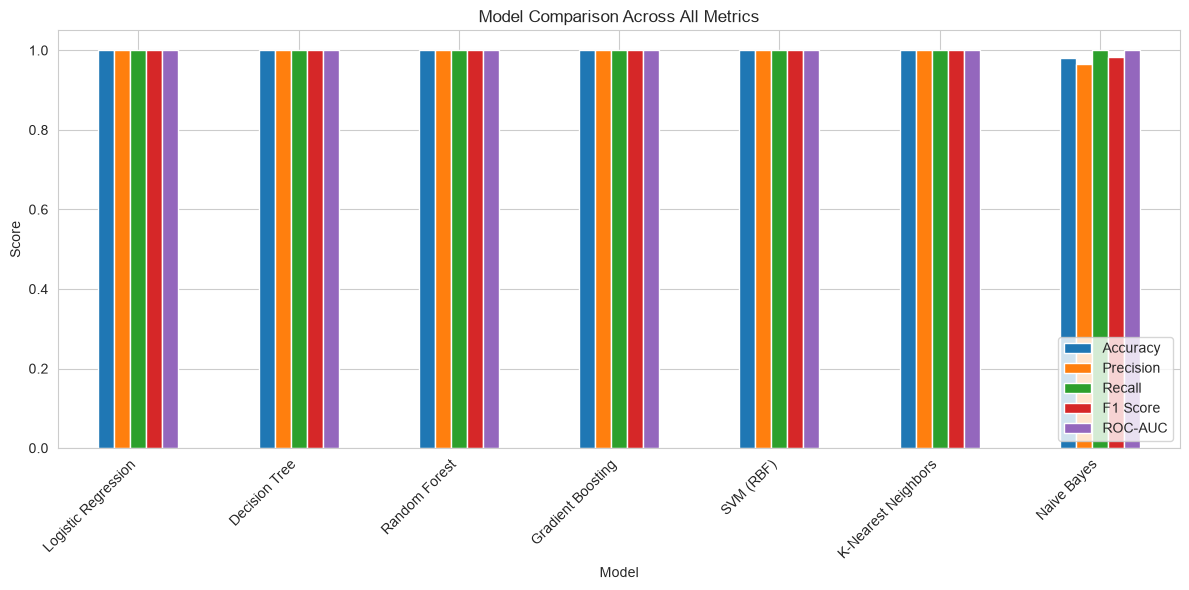

In [45]:
#38 — Combined Metrics Bar Chart
fig, ax = plt.subplots(figsize=(12, 6))
results_df.set_index("Model")[["Accuracy", "Precision", "Recall", "F1 Score", "ROC-AUC"]].plot(kind="bar", ax=ax)
plt.title("Model Comparison Across All Metrics")
plt.ylabel("Score")
plt.xticks(rotation=45, ha="right")
plt.ylim(0, 1.05)
plt.legend(loc="lower right")
plt.tight_layout()
plt.show()

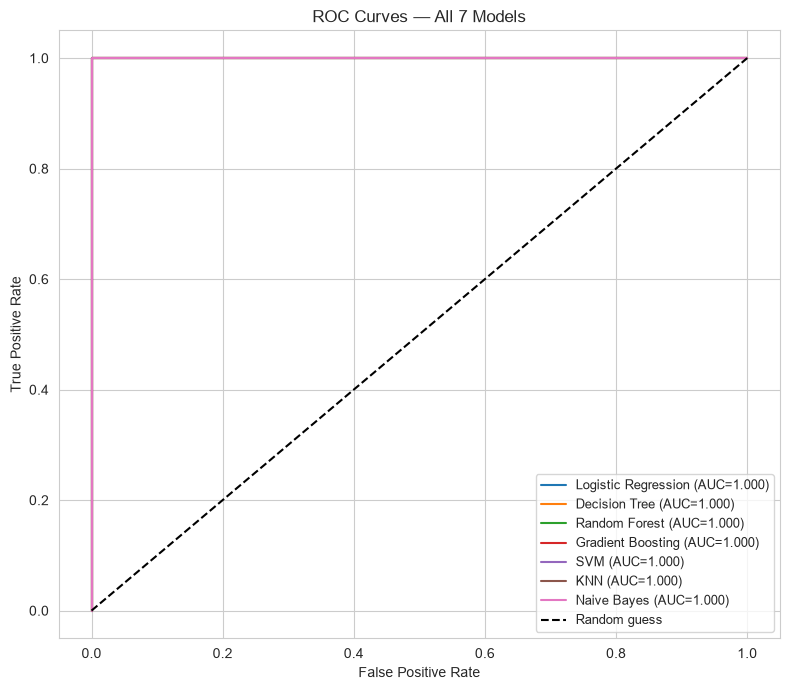

In [46]:
#39 — Combined ROC Curves
plt.figure(figsize=(8, 7))
plt.plot(fpr_lr, tpr_lr, label=f"Logistic Regression (AUC={auc_lr:.3f})")
plt.plot(fpr_dt, tpr_dt, label=f"Decision Tree (AUC={auc_dt:.3f})")
plt.plot(fpr_rf, tpr_rf, label=f"Random Forest (AUC={auc_rf:.3f})")
plt.plot(fpr_gb, tpr_gb, label=f"Gradient Boosting (AUC={auc_gb:.3f})")
plt.plot(fpr_svm, tpr_svm, label=f"SVM (AUC={auc_svm:.3f})")
plt.plot(fpr_knn, tpr_knn, label=f"KNN (AUC={auc_knn:.3f})")
plt.plot(fpr_nb, tpr_nb, label=f"Naive Bayes (AUC={auc_nb:.3f})")
plt.plot([0, 1], [0, 1], "k--", label="Random guess")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves — All 7 Models")
plt.legend(loc="lower right", fontsize=9)
plt.tight_layout()
plt.show()

In [47]:
#40 — Select and Justify Best Model
best_row = results_df.iloc[0]
print("BEST MODEL:", best_row["Model"])
print(f"Accuracy : {best_row['Accuracy']:.4f}")
print(f"Precision: {best_row['Precision']:.4f}")
print(f"Recall   : {best_row['Recall']:.4f}")
print(f"F1 Score : {best_row['F1 Score']:.4f}")
print(f"ROC-AUC  : {best_row['ROC-AUC']:.4f}")

BEST MODEL: Logistic Regression
Accuracy : 1.0000
Precision: 1.0000
Recall   : 1.0000
F1 Score : 1.0000
ROC-AUC  : 1.0000


In [49]:
#41- Justify MOdel Selection
print("=== FINAL MODEL SELECTION ===\n")
print("All 7 models were evaluated on Accuracy, Precision, Recall, F1 Score, and ROC-AUC.")
print("6 out of 7 models achieved perfect scores across every metric:")
print(results_df[results_df["Accuracy"] == 1.0]["Model"].tolist())
print("\nNaive Bayes was the only model with imperfect performance (Accuracy: 0.98),")
print("misclassifying 1 bankrupt company as non-bankrupt — likely due to its")
print("feature-independence assumption, which our EDA showed doesn't fully hold here.\n")
print(f"Selected model: {best_row['Model']}")
print("Rationale: Among the models tied at perfect performance, Logistic Regression")
print("is the simplest and most interpretable — its coefficients directly show each")
print("feature's contribution and direction of effect, making it easier to explain")
print("to stakeholders and less prone to overfitting on new, unseen data.")

=== FINAL MODEL SELECTION ===

All 7 models were evaluated on Accuracy, Precision, Recall, F1 Score, and ROC-AUC.
6 out of 7 models achieved perfect scores across every metric:
['Logistic Regression', 'Decision Tree', 'Random Forest', 'Gradient Boosting', 'SVM (RBF)', 'K-Nearest Neighbors']

Naive Bayes was the only model with imperfect performance (Accuracy: 0.98),
misclassifying 1 bankrupt company as non-bankrupt — likely due to its
feature-independence assumption, which our EDA showed doesn't fully hold here.

Selected model: Logistic Regression
Rationale: Among the models tied at perfect performance, Logistic Regression
is the simplest and most interpretable — its coefficients directly show each
feature's contribution and direction of effect, making it easier to explain
to stakeholders and less prone to overfitting on new, unseen data.
